# Week 5: Dynamic Hedging Simulation

This notebook extends the single-path delta hedging table from [Week 4](../week4_greeks/greeks.ipynb) 
to 1000 independent GBM paths. Where Week 4 asked *"does the hedge work?"*, 
Week 5 asks *"what does the distribution of hedging outcomes look like across many paths?"*

## Setup

Same parameters as Week 4's hedging table — same stock, same option, same 20-week horizon.

In [1]:
from scipy.stats import norm
from math import log, sqrt, exp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Setup inputs
s_0 = 49
k = 50
r = 0.05
mu = 0.15
sigma = 0.30
T = 20/52        # 20 weeks in years
N = 20     # one step per week
dt = T / N # = 1/52
num_paths = 1000
n_options = 100000

# Generating random draws
Z = np.random.standard_normal((num_paths, N))

## Generating 1000 GBM Paths

Recall from Week 1 that GBM evolves the stock price as:

$$S_{t+1} = S_t \cdot \exp\left(\left(\mu - \frac{\sigma^2}{2}\right)\Delta t + \sigma \sqrt{\Delta t} \cdot Z\right)$$

Each simulation produces $N+1$ price points — weekly snapshots from $S_0$ through $S_{20}$. 
We generate 1000 independent paths, each a possible future for the stock.

In [2]:
#  Building price paths in GBM
prices = np.zeros ((num_paths, N+1))
prices[:, 0] = s_0         
for t in range(1, N+1):
            prices[:, t] = prices[:, t-1] * np.exp((mu - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * Z[:, t-1])

# Show a sample of values from GBM walk
np.set_printoptions(precision=2, suppress=True)
print(prices[:3])

[[49.   49.67 49.51 47.79 52.01 49.67 50.54 51.16 51.96 55.57 56.92 56.71
  62.03 62.67 59.78 60.47 60.38 59.96 56.13 56.56 59.04]
 [49.   46.72 49.52 52.18 51.64 52.27 51.51 50.78 51.47 54.3  55.91 54.82
  53.76 55.58 53.9  52.87 53.66 50.18 45.59 46.08 47.62]
 [49.   47.45 50.9  51.13 52.05 55.84 54.31 53.57 50.39 47.91 46.62 46.29
  49.59 49.89 51.48 52.29 55.33 54.27 53.61 52.88 50.99]]


## BSM Functions

We reuse the BSM pricer and delta function from Week 3 and Week 4. 
At each hedging step, BSM is called with the *current stock price* and *time remaining* 
to get the current delta — how many shares we should be holding right now.

In [3]:

# Function for d1 and d2
def d_1(sigma, s_0, k, r, T):
    d_1 = (log(s_0/k)+(r+(sigma**2)/2)*T)/((sigma)*sqrt(T))
    return d_1

def d_2(sigma, s_0, k, r, T): 
    return d_1(sigma, s_0, k, r, T) - (sigma)*sqrt(T)

# Identifying option prices using BSM
def compute_delta_hedge(sigma, S, k, r, T_remaining):
    if T_remaining <= 0:
        return 1.0 if S > k else 0.0
    return norm.cdf(d_1(sigma, S, k, r, T_remaining))

# BSM call pricer only
def bsm(sigma, s_0, k, r, T):
    d1 = d_1(sigma, s_0, k, r, T)
    d2 = d_2(sigma, s_0, k, r, T)
    opt_price = s_0 * norm.cdf(d1) - k * exp(-r * T) * norm.cdf(d2)
    return opt_price

# Compute options cost with BSM:
bsm_price = bsm(sigma, s_0, k, r, T) * n_options



## The Hedge Account

Rather than tracking gross share purchases and sales separately, we model a single 
**hedge account** — think of it as the cash account funding the hedging operation.

It works like this:

| Event | Effect on account |
|-------|-------------------|
| t = 0 | Seeded with BSM premium collected from selling the option |
| Each week | Grown by one period of interest $e^{r \Delta t}$, then debited/credited for share rebalancing |
| Expiry | Credited for liquidating remaining share position, debited for option payoff if ITM |

The P&L for each path is simply whatever remains in the account at expiry:

$$\text{P\&L} = \text{hedge account at } T$$

If BSM were perfect and hedging were continuous, this would be exactly zero on every path. 
Discrete weekly rehedging introduces residual error — the distribution of that error 
across 1000 paths is what we are studying.

In [4]:
# Build pnl list
def compute_pnl(k, r, prices, bsm_price, N, T, dt, sigma, n_options, num_paths):
    pnl_list = []

    for i in range(num_paths):
        stock_prices = prices[i]
        
        hedge_account = bsm_price  # start with premium collected
        shares_held = 0.0
        
        for t in range(N):
            # Grow account by one period of interest
            hedge_account *= exp(r * dt)
            
            # Compute new delta
            T_remaining = T - t * dt
            new_delta = compute_delta_hedge(sigma, stock_prices[t], k, r, T_remaining)
            
            # Rebalance: buy/sell shares
            shares_to_trade = new_delta * n_options - shares_held
            hedge_account -= shares_to_trade * stock_prices[t]
            shares_held = new_delta * n_options  # already in share units
        
        # Expiry: liquidate shares, pay option payoff
        hedge_account += shares_held * stock_prices[-1]
        option_payoff = max(stock_prices[-1] - k, 0) * n_options
        hedge_account -= option_payoff
        
        pnl_list.append(hedge_account)
    return pnl_list

## P&L Distribution Across 1000 Paths

With 1000 final P&L values collected, we plot the distribution. Two things to look for:

- **Mean ≈ 0** — the hedge is fair on average; BSM premium is the correct price
- **Spread/Standard Deviation** — the width of the distribution is the discrete hedging error; 
  residual risk from rebalancing only once per week

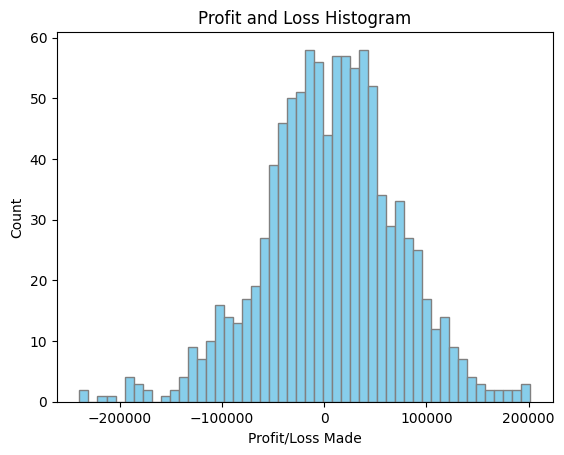

Mean is: 6125.13
Discrete Hedging Error is: 65576.02


In [5]:
pnl_weekly = compute_pnl(k, r, prices, bsm_price, N, T, dt, sigma, n_options, num_paths)
plt.hist(pnl_weekly, bins=50, color="skyblue", edgecolor="gray")

plt.xlabel("Profit/Loss Made")
plt.ylabel("Count")
plt.title("Profit and Loss Histogram")

plt.show()
print(f"Mean is: {np.mean(pnl_weekly):.2f}")
print(f"Discrete Hedging Error is: {np.std(pnl_weekly):.2f}")

## Effect of Hedging Frequency

How often should you rehedge? More frequent rehedging tracks delta more closely, 
reducing hedging error. But in real markets every trade has transaction costs — 
continuous rehedging is not free. This is one of the central tensions in options market-making.

We test three frequencies over the same 20-week horizon by changing the step size:

| Frequency | Steps | $\Delta t$ |
|-----------|-------|------------|
| Biweekly | 10 | 2/52 |
| Weekly | 20 | 1/52 |
| Daily | 140 | 1/252 |

The same hedge account logic applies at each frequency — only $N$ and $\Delta t$ change.

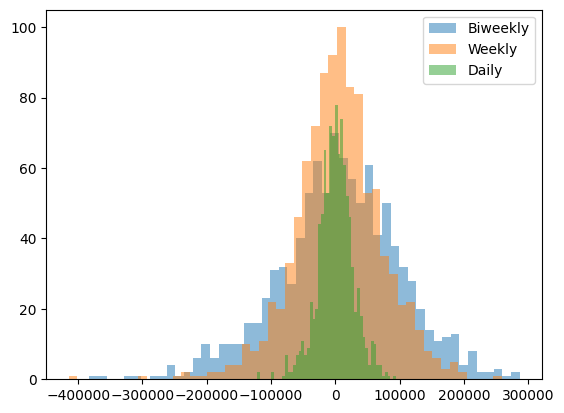

This is the mean and the standard deviation at different frequencies:
               10            20            140
mean   6217.514564   4892.641701    445.093246
std   95562.622797  68167.535548  27393.598286


In [6]:
# Collecting the histogram for different frequencies over the same 20 week period
N_list = [10, 20, 140]
pnl_results = {}

for N_freq in N_list:
    dt_freq = T / N_freq

    # Generate new GBM paths for the different N_freqs
    Z = np.random.standard_normal((num_paths, N_freq))
    prices_freq = np.zeros ((num_paths, N_freq + 1))
    prices_freq [:, 0] = s_0         
    for t in range(1, N_freq + 1):
        prices_freq[:, t] = prices_freq[:, t-1] * np.exp((mu - 0.5 * sigma ** 2) * dt_freq + sigma * np.sqrt(dt_freq) * Z[:, t-1])
    
    pnl_results[N_freq] = compute_pnl(k, r, prices_freq, bsm_price, N_freq, T, dt_freq, sigma, n_options, num_paths)

pnl_df = pd.DataFrame(pnl_results)

# Plotting different frequencies
labels = {10: 'Biweekly', 20: 'Weekly', 140: 'Daily'}
for N_freq, pnl in pnl_results.items():
    plt.hist(pnl, bins=50, alpha=0.5, label=labels[N_freq])
plt.legend()
plt.show()

# Create summary for the P&L distributions at different frequencies
pnl_summary = pnl_df.agg(['mean', 'std'])

print("This is the mean and the standard deviation at different frequencies:")
print(pnl_summary)

## Why Gamma Determines Hedging Error

The residual error per path is not random — it is related to **gamma** ($\Gamma$), 
the rate of change of delta with respect to the stock price:

$$\Gamma = \frac{\partial^2 C}{\partial S^2}$$

When gamma is high, delta changes rapidly with small stock moves. A weekly hedge 
rebalances too infrequently to keep up, leaving larger residual error. When gamma 
is low, delta is stable and the weekly hedge tracks well.

This is why gamma is sometimes called the *hedging difficulty* Greek — 
it quantifies how fast your hedge goes stale between rebalancing points.

Below we plot average gamma along each path against that path's absolute P&L.

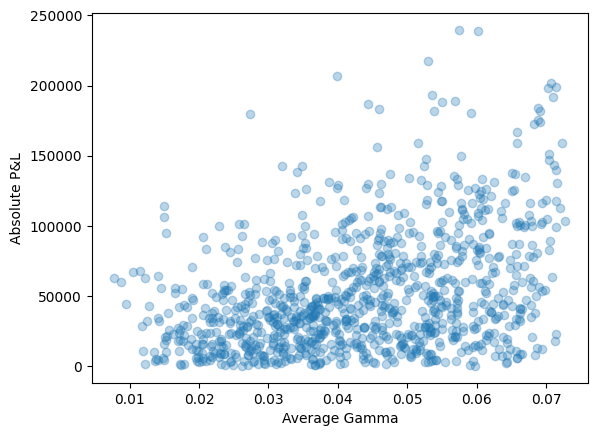

In [8]:
# Compute for gamming finite differences
def compute_gamma(S, T_remaining):
    if T_remaining <= 0:
        return 0.0
    h = S * 0.005
    price = bsm(sigma, S, k, r, T_remaining)
    up = bsm(sigma, S + h, k, r, T_remaining)
    down = bsm(sigma, S - h, k, r, T_remaining)
    return (up - 2 * price + down)/(h ** 2)

gamma_list = []
for i in range(num_paths):
    stock_prices = prices[i, :-1] # excluding expiry
    gammas = [compute_gamma(S, T - t * dt) for t, S in enumerate(stock_prices)]
    gamma_list.append(np.mean(gammas))

# Plot the scatter graph
plt.scatter(gamma_list, np.abs(pnl_weekly), alpha=0.3)
plt.xlabel("Average Gamma")
plt.ylabel("Absolute P&L")
plt.show()